# CH₄ → CH₃• + H•  —  reactive MLIP + free-energy barrier (Colab)

Trains a plain **DeePMD `se_e2_a`** potential for the **first C–H scission** of a
single methane molecule in vacuum, then drives the bond break with
**ASE + PLUMED well-tempered metadynamics** along the **C–H coordination number**
and extracts the dissociation **free-energy barrier**.

**Stack (all conda-forge, no LAMMPS):**
DFT = **Psi4 UB3LYP/def2-TZVP** (open-shell, broken-symmetry singlet) ·
ML = **DeePMD-kit** (`se_e2_a`, energy+forces) ·
MD+bias = **ASE Langevin + PLUMED** (`ase.calculators.plumed`).

**Physics notes baked in:**
* Spin: `reference uks` + `guess_mix true` → the bond dissociates **homolytically**
  (CH₃•+H•), not into ions. A restricted singlet would give the wrong curve.
* The freed H is kept in range by **UPPER_WALLS at 3.5 Å** so the FES converges.
* No periodicity/virial — it's a molecule. A nominal 20 Å box is only there to
  keep the bias engine happy.

### How to use
1. Runtime can be **CPU** (GPU unnecessary — 5 atoms).
2. **Run the condacolab cell, WAIT for the kernel to restart, then run `check()`.**
   That restart is the #1 gotcha — don't run ahead of it.
3. Then run top to bottom. Each stage prints a **GATE** line so you know it passed.


## 1 · Install micromamba — this RESTARTS the kernel

In [47]:
import os, subprocess

# Install micromamba (a small standalone conda-compatible package manager,
# no kernel restart required, no symlink patching of system python)
subprocess.run(
    "curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj bin/micromamba",
    shell=True, check=True
)

MAMBA_ROOT = "/content/micromamba"
ENV_NAME = "ch4mlip"
ENV_PREFIX = f"{MAMBA_ROOT}/envs/{ENV_NAME}"
os.environ["MAMBA_ROOT_PREFIX"] = MAMBA_ROOT

# Create the env with everything you need, straight from conda-forge --
# same packages, same builds, as the condacolab route.
subprocess.run(
    f"./bin/micromamba create -y -p {ENV_PREFIX} -c conda-forge "
    f"python=3.11 psi4 deepmd-kit plumed py-plumed ase matplotlib numpy",
    shell=True, check=True
)

print("micromamba env created at", ENV_PREFIX)

micromamba env created at /content/micromamba/envs/ch4mlip


## 2 · Verify conda is live (run AFTER the restart)

In [48]:
import glob, subprocess, os

PY = f"{ENV_PREFIX}/bin/python"
assert os.path.exists(PY), f"expected python at {PY} but it's missing -- check cell 1 output for install errors"

conda_bin = os.path.dirname(PY)

# point PLUMED at its kernel lib, same as before
ker = glob.glob(f"{ENV_PREFIX}/lib/libplumedKernel.so")
if ker:
    os.environ["PLUMED_KERNEL"] = ker[0]
    print("PLUMED_KERNEL =", ker[0])
else:
    print("WARN: libplumedKernel not found yet")

check = subprocess.run(
    [PY, "-c", "import psi4, deepmd, ase, plumed; print('all good')"],
    capture_output=True, text=True
)
print(check.stdout)
if check.stderr.strip():
    print("--- stderr ---"); print(check.stderr)

print("GATE 0", "OK" if "all good" in check.stdout else "FAILED", "- conda env ready, PY =", PY)    # should say: everything looks OK!

PLUMED_KERNEL = /content/micromamba/envs/ch4mlip/lib/libplumedKernel.so
all good

GATE 0 OK - conda env ready, PY = /content/micromamba/envs/ch4mlip/bin/python


In [ ]:
import subprocess
# list everything actually installed in the env
result = subprocess.run(
    [f"{conda_bin}/micromamba" if False else "./bin/micromamba", "list", "-p", ENV_PREFIX],
    capture_output=True, text=True
)
print(result.stdout)

List of packages in environment: "/content/micromamba/envs/ch4mlip"

  Name                       Version       Build                          Channel    
───────────────────────────────────────────────────────────────────────────────────────
  _openmp_mutex              4.5           7_kmp_llvm                     conda-forge
  _x86_64-microarch-level    3             3_x86_64_v3                    conda-forge
  absl-py                    2.4.0         pyhd8ed1ab_0                   conda-forge
  alsa-lib                   1.2.16.1      hb03c661_0                     conda-forge
  annotated-types            0.7.0         pyhd8ed1ab_1                   conda-forge
  armadillo                  15.4.0        h7dbe251_0                     conda-forge
  arpack                     3.9.1         nompi_hf03ea27_102             conda-forge
  array-api-compat           1.15.0        pyhc364b38_0                   conda-forge
  ase                        3.28.0        pyhd8ed1ab_1              

# Stage A · Generate geometries + label with Psi4 (UB3LYP)
A relaxed-ish bond **scan** (one C–H from 1.0→3.5 Å) plus **random rattling**, each
geometry labeled with open-shell UB3LYP/def2-TZVP. Writes a DeePMD dataset
(`data/`) with energies (eV) and forces (eV/Å). ~120 single points, seconds each.

In [49]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.environ['CH4_ROOT'] = '/content/drive/MyDrive/ch4-mlip'   # everything persists here
os.makedirs(os.environ['CH4_ROOT'], exist_ok=True)
print('persisting to', os.environ['CH4_ROOT'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
persisting to /content/drive/MyDrive/ch4-mlip


In [ ]:
%%writefile gen_and_label.py
import numpy as np, os, glob
import psi4

# ---------- persistence (survives disconnects) ----------
ROOT   = os.environ.get("CH4_ROOT", "/content/ch4-mlip")   # falls back to local
FRAMES = os.path.join(ROOT, "frames")                      # one file per labeled frame
DATA   = os.path.join(ROOT, "data")                        # assembled DeePMD dataset
os.makedirs(FRAMES, exist_ok=True)
os.makedirs(os.path.join(DATA, "set.000"), exist_ok=True)

HART2EV = 27.211386245988
BOHR2A  = 0.529177210903
F_CONV  = HART2EV / BOHR2A      # Hartree/Bohr -> eV/A

psi4.set_memory('2 GB')
psi4.core.set_num_threads(2)
psi4.set_output_file('psi4_out.log', False)      # log stays local; not needed on Drive
psi4.set_options({'reference':'uks', 'guess_mix':True, 'maxiter':250,
                  'basis':'def2-tzvp', 'scf_type':'df'})

SYM = ['C','H','H','H','H']
def ch4(bond=1.087):
    d = np.array([[1,1,1],[1,-1,-1],[-1,1,-1],[-1,-1,1]], float)
    d /= np.linalg.norm(d, axis=1, keepdims=True)
    return np.vstack([[0,0,0], d*bond])

def make_mol(pos):
    lines = ["0 1"]
    for s,p in zip(SYM,pos):
        lines.append(f"{s} {p[0]:.8f} {p[1]:.8f} {p[2]:.8f}")
    lines += ["units angstrom","symmetry c1","no_com","no_reorient"]
    return psi4.geometry("\n".join(lines))

def label(pos):
    mol = make_mol(pos)
    try:
        g, wfn = psi4.gradient('b3lyp', molecule=mol, return_wfn=True)
    except Exception as e:
        print("  SCF/gradient failed:", e); return None
    grad   = np.array(g)
    coords = mol.geometry().to_array()*BOHR2A
    energy = wfn.energy()*HART2EV
    force  = -grad*F_CONV
    return coords, energy, force

# ---------- deterministic pool (identical every run -> stable indices) ----------
rng = np.random.default_rng(0)
eq  = ch4()
pool = []
for h_idx in range(1, 5):                        # stretch each of the 4 C-H bonds
    u = (eq[h_idx]-eq[0]); u /= np.linalg.norm(u)
    for d in np.linspace(1.0, 3.5, 22):
        base = eq.copy(); base[h_idx] = eq[0] + u*d
        pool.append(base)
        for _ in range(10):
            pool.append(base + rng.normal(0, 0.08, size=base.shape))
for _ in range(22):
    pool.append(eq + rng.normal(0, 0.10, size=eq.shape))
N = len(pool)

# ---------- atomic per-frame save (no half-written files on disconnect) ----------
def fpath(i): return os.path.join(FRAMES, f"frame_{i:05d}.npz")
def save_atomic(path, **arr):
    tmp = path + ".tmp"
    with open(tmp, "wb") as fh:
        np.savez(fh, **arr)
    os.replace(tmp, path)                         # atomic rename

# ---------- RESUME: skip frames already on Drive ----------
done = {int(os.path.basename(f)[6:11]) for f in glob.glob(os.path.join(FRAMES, "frame_*.npz"))}
print(f"resuming: {len(done)}/{N} frames already labeled, {N-len(done)} to go")

for i, p in enumerate(pool):
    if i in done:
        continue
    try:
        r = label(p)
        if r is None:
            save_atomic(fpath(i), failed=np.array([1]))     # mark so we don't retry forever
            continue
        c, e, f = r
        save_atomic(fpath(i), coord=c, energy=np.array([e]), force=f, ok=np.array([1]))
    except Exception as e:
        print("  frame", i, "errored:", e)
        continue
    if i % 10 == 0:
        nd = len(glob.glob(os.path.join(FRAMES, "frame_*.npz")))
        print(f"{i}/{N}  done={nd}  E={e:.3f} eV")

# ---------- assemble DeePMD dataset from all good frames (idempotent) ----------
C, E, F = [], [], []
for fp in sorted(glob.glob(os.path.join(FRAMES, "frame_*.npz"))):
    z = np.load(fp)
    if "ok" not in z.files:                       # skip failed markers
        continue
    C.append(z["coord"].reshape(-1)); E.append(float(z["energy"][0])); F.append(z["force"].reshape(-1))
C = np.array(C); E = np.array(E); F = np.array(F)

np.save(os.path.join(DATA, "set.000", "coord.npy"),  C)
np.save(os.path.join(DATA, "set.000", "energy.npy"), E)
np.save(os.path.join(DATA, "set.000", "force.npy"),  F)
np.save(os.path.join(DATA, "set.000", "box.npy"), np.tile((np.eye(3)*20.0).reshape(-1), (len(E),1)))
open(os.path.join(DATA, "type.raw"), "w").write("0\n1\n1\n1\n1\n")
open(os.path.join(DATA, "type_map.raw"), "w").write("C\nH\n")
open(os.path.join(DATA, "nopbc"), "w").write("")

# mirror to fast local disk for training IO
import shutil
if os.path.exists("data"): shutil.rmtree("data")
shutil.copytree(DATA, "data")
print(f"ASSEMBLED {len(E)} good frames -> {DATA}  (and mirrored to ./data)")

Writing gen_and_label.py


In [ ]:
!{PY} gen_and_label.py
import os
ok = os.path.exists('data/set.000/energy.npy')
print('GATE A', 'OK' if ok else 'FAILED', '- DFT dataset (also saved on Drive)')


  Memory set to   1.863 GiB by Python driver.
  Threads set to 2 by Python driver.
resuming: 990/990 frames already labeled, 0 to go
ASSEMBLED 990 good frames -> /content/drive/MyDrive/ch4-mlip/data  (and mirrored to ./data)
GATE A OK - DFT dataset (also saved on Drive)


# Stage B · Train the DeePMD potential
Plain `se_e2_a`, energy+forces, non-periodic.

In [ ]:
%%writefile input.json
{
  "model": {
    "type_map": ["C","H"],
    "descriptor": {"type":"se_e2_a","sel":[4,8],"rcut_smth":0.5,"rcut":6.0,
                   "neuron":[25,50,100],"axis_neuron":16,"seed":1},
    "fitting_net": {"type":"ener","neuron":[120,120,120],"resnet_dt":true,"seed":1}
  },
  "learning_rate": {"type":"exp","start_lr":0.001,"stop_lr":3.5e-08,"decay_steps":2000},
  "loss": {"type":"ener","start_pref_e":0.1,"limit_pref_e":1,
           "start_pref_f":1000,"limit_pref_f":1,"start_pref_v":0,"limit_pref_v":0},
  "training": {
    "training_data": {"systems":["./data"],"batch_size":"auto"},
    "numb_steps":60000,"seed":1,"disp_file":"lcurve.out","disp_freq":200,"save_freq":2000
  }
}

Writing input.json


In [ ]:
import os
conda_bin = os.path.dirname(PY)
dp_bin = os.path.join(conda_bin, 'dp')

os.environ['MPLBACKEND'] = 'Agg'   # fix for dp's matplotlib import crash
!{dp_bin} train input.json
!{dp_bin} freeze

import glob
m = glob.glob('frozen_model.*')
print('GATE B', 'OK' if m else 'FAILED', '- model:', m)

To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
Switch to serial execution due to lack of horovod module.
[2026-06-20 08:45:31,235] DEEPMD INFO    Calculate neighbor statistics... (add --skip-neighbor-stat to skip this step)
[2026-06-20 08:45:31,243] DEEPMD WARNING You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
I0000 00:00:1781945131.412127    8669 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
[2026-06-20 08:45:31,526] DEEPMD INFO    Neighbor statistics: training data with minimal neighbor distance: 0.712785
[2026-06-20 08:45:31,526] DEEPMD INFO    Neighbor statistics: training data with maximum neighbor size: [1 4] (cutoff radius: 6.000000)
[2026-06-

# Stage C · Metadynamics with ASE + PLUMED
Langevin MD at 300 K with the trained potential, biased along the C–H
coordination number; UPPER_WALLS keep the freed H within 3.5 Å so the run
refluxes and the FES converges.

In [57]:
%%writefile run_metad.py
import os, glob, numpy as np
if 'PLUMED_KERNEL' not in os.environ:
    ker = glob.glob('/content/micromamba/envs/ch4mlip/lib/libplumedKernel.so')
    if ker: os.environ['PLUMED_KERNEL'] = ker[0]

from ase import Atoms, units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.calculators.plumed import Plumed
from deepmd.calculator import DP

model = sorted(glob.glob("frozen_model.*"))[0]; print("model:", model)
d = np.array([[1,1,1],[1,-1,-1],[-1,1,-1],[-1,-1,1]], float)
d /= np.linalg.norm(d, axis=1, keepdims=True)
atoms = Atoms("CH4", positions=np.vstack([[0,0,0], d*1.087]), cell=[20,20,20], pbc=True)
atoms.center()

def coordination(p, r0=1.4, nn=6, mm=12):
    s = np.linalg.norm(p[1:] - p[0], axis=1)/r0
    return float(np.sum((1 - s**nn)/(1 - s**mm)))
c0 = coordination(atoms.get_positions())
print(f"starting c = {c0:.3f} (intact CH4 ~3.28)")

ps, ts = 1000*units.fs, 0.25*units.fs        # 0.25 fs: smaller per-step jumps
plumed_input = [
  f"UNITS LENGTH=A TIME={1/ps} ENERGY={units.mol/units.kJ}",
  "c: COORDINATION GROUPA=1 GROUPB=2,3,4,5 R_0=1.4 NN=6 MM=12",
  "d1: DISTANCE ATOMS=1,2", "d2: DISTANCE ATOMS=1,3",
  "d3: DISTANCE ATOMS=1,4", "d4: DISTANCE ATOMS=1,5",
  # cap each C-H so a freed H can't escape
  "uw: UPPER_WALLS ARG=d1,d2,d3,d4 AT=3.5,3.5,3.5,3.5 KAPPA=200.0,200.0,200.0,200.0",
  # confine c to the first-scission window [2.40, 3.45] with MODERATE walls
  "lwc: LOWER_WALLS ARG=c AT=2.40 KAPPA=500.0",
  "uwc: UPPER_WALLS ARG=c AT=3.45 KAPPA=500.0",
  # grid restored for speed. Range [2.0,3.8] sits 0.4/0.35 BEYOND the c-walls,
  # so c (held inside [2.40,3.45]) can never reach an edge -> no grid crash.
  "metad: METAD ARG=c PACE=100 HEIGHT=1.2 SIGMA=0.05 BIASFACTOR=10 TEMP=300 ",

  "PRINT ARG=c,d1,d2,d3,d4,metad.bias STRIDE=20 FILE=COLVAR",
  "FLUSH STRIDE=200",
]
atoms.calc = Plumed(calc=DP(model=model), input=plumed_input,
                    timestep=ts, atoms=atoms, kT=units.kB*300)
MaxwellBoltzmannDistribution(atoms, temperature_K=300)
dyn = Langevin(atoms, ts, temperature_K=300, friction=0.1)   # 0.1: damps runaway
dyn.run(200000)   # 200000 * 0.25 fs = 50 ps
print("METAD done")

Overwriting run_metad.py


In [58]:
# delete any stale bias/colvar files so we never re-read an old run
!rm -f HILLS COLVAR KERNELS STATE* fes.dat bck.* 2>/dev/null
print("cleaned stale HILLS/COLVAR/fes files")


cleaned stale HILLS/COLVAR/fes files


In [59]:
!{PY} run_metad.py
import os, numpy as np
ok = os.path.exists('HILLS')
if os.path.exists('COLVAR'):
    c = np.loadtxt('COLVAR'); print('CV range reached:', round(c[:,1].min(),2), '->', round(c[:,1].max(),2),
          '(want it to dip toward ~3 => a C-H broke)')
print('GATE C', 'OK' if ok else 'FAILED', '- HILLS')

model: frozen_model.pb
starting c = 3.281 (intact CH4 ~3.28)
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
I0000 00:00:1781967089.360559   97327 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/content/micromamba/envs/ch4mlip/lib/libplumedKernel.so" +++
PLUMED: PLUMED is starting
PLUMED: Version: 2.10.0 (git: Unknown) compiled on May 18 2026 at 20:11:18
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /content/micromamba/envs/ch4mlip/lib/plume

# Stage D · Free-energy profile + barrier

PLUMED: PLUMED is starting
PLUMED: Version: 2.10.0 (git: Unknown) compiled on May 18 2026 at 20:11:18
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /content/micromamba/envs/ch4mlip/lib/plumed
PLUMED: LibraryPath: /content/micromamba/envs/ch4mlip/bin/../lib/libplumedKernel.so
PLUMED: For installed feature, see /content/micromamba/envs/ch4mlip/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: mdcode
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 1
PLUMED: File suffix: 
PLUMED: KbT has not been set by the MD engine
PLUMED: It should be set by hand where needed
PLUMED: Relevant bibliography:
PLUMED:   [1] The PLUMED consortium, Nat. Methods 16, 670 (2019)
PLUMED:   [2] Tribello, Bonomi, Branduardi, Camilloni, and Bussi, Comput. Phys. Commun. 185, 604 (2014)
PLUMED: Please re

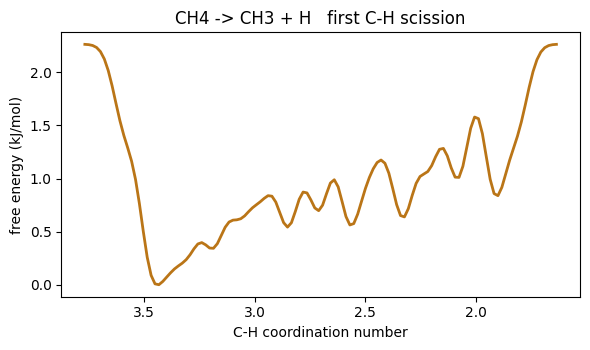

GATE D OK -> fes_ch4.png


In [60]:
import os, numpy as np, matplotlib.pyplot as plt
conda_bin = os.path.dirname(PY); plumed_bin = os.path.join(conda_bin, 'plumed')
!{plumed_bin} sum_hills --hills HILLS --outfile fes.dat --mintozero

d = np.loadtxt('fes.dat'); cv, F = d[:,0], d[:,1]; F = F - F.min()
print(f"CV range in fes.dat: {cv.min():.2f} -> {cv.max():.2f}")
print("(reactant CH4 ~3.2-3.3, product CH3+H ~2.4-2.6)")

def basin(lo, hi, label):
    m = (cv > lo) & (cv < hi)
    if not m.any():
        print(f"  WARNING: {label} region {lo}-{hi} unsampled"); return np.nan
    return F[m].min()
reac = basin(3.15, 3.35, "reactant"); prod = basin(2.40, 2.65, "product")
pm = (cv > 2.65) & (cv < 3.15); peak = F[pm].max() if pm.any() else np.nan
kcal = 1/4.184
if not np.isnan(reac) and not np.isnan(peak):
    print(f"barrier (forward) ~ {peak-reac:.0f} kJ/mol ({(peak-reac)*kcal:.0f} kcal/mol)")
else:
    print("barrier -> reactant or barrier region unsampled (bond didn't break)")
if not np.isnan(reac) and not np.isnan(prod):
    print(f"reaction dF ~ {prod-reac:.0f} kJ/mol ({(prod-reac)*kcal:.0f} kcal/mol)")
else:
    print("reaction dF -> product unsampled")

plt.figure(figsize=(6,3.6)); plt.plot(cv, F, lw=2, color='#BA7517')
plt.xlabel('C-H coordination number'); plt.ylabel('free energy (kJ/mol)')
plt.title('CH4 -> CH3 + H   first C-H scission'); plt.gca().invert_xaxis()
plt.tight_layout(); plt.savefig('fes_ch4.png', dpi=150); plt.show()
print('GATE D OK -> fes_ch4.png')


# Stage E · Active Learning loop (committee → explore → select → relabel → retrain)

In [ ]:
%%writefile al.py
"""al.py -- active-learning loop (DP-GEN-style) for the CH4 -> CH3 + H notebook.

Self-contained: committee training, METAD exploration, committee force-deviation,
band selection + Psi4 re-labelling, and the recursive driver. Reuses the SAME
Drive-backed frame store that gen_and_label.py created (CH4_ROOT/frames), so the
bootstrap set seeds iteration 0 automatically.

Micromamba-aware: when launched as  !{PY} al.py ...  , sys.executable is the env
python, so the env's `dp` binary and libplumedKernel are found next to it -- no
reliance on a bare `dp`/`plumed` on PATH.
"""
import os, sys, glob, json, argparse, subprocess, shutil
import numpy as np

# ---------------------------------------------------------------- env / paths
ENV_BIN  = os.path.dirname(sys.executable)                 # .../envs/ch4mlip/bin
ENV_ROOT = os.path.dirname(ENV_BIN)
DP_BIN   = os.path.join(ENV_BIN, "dp")
if not os.path.exists(DP_BIN):
    DP_BIN = "dp"                                          # fallback to PATH
if "PLUMED_KERNEL" not in os.environ:
    ker = glob.glob(os.path.join(ENV_ROOT, "lib", "libplumedKernel.so"))
    if ker:
        os.environ["PLUMED_KERNEL"] = ker[0]

ROOT   = os.environ.get("CH4_ROOT", os.path.abspath("al_run"))
FRAMES = os.path.join(ROOT, "frames")        # shared with gen_and_label.py
DATA   = os.path.join(ROOT, "data")
MODELS = os.path.join(ROOT, "models")
for d in (FRAMES, MODELS):
    os.makedirs(d, exist_ok=True)

HART2EV = 27.211386245988
BOHR2A  = 0.529177210903
F_CONV  = HART2EV / BOHR2A
SYM   = ["C", "H", "H", "H", "H"]
ATYPE = [0, 1, 1, 1, 1]
BOX   = (np.eye(3) * 20.0).reshape(-1)

INPUT_TEMPLATE = """{
  "model": {
    "type_map": ["C","H"],
    "descriptor": {"type":"se_e2_a","sel":[4,8],"rcut_smth":0.5,"rcut":6.0,
                   "neuron":[25,50,100],"axis_neuron":16,"seed":__SEED__},
    "fitting_net": {"type":"ener","neuron":[120,120,120],"resnet_dt":true,"seed":__SEED__}
  },
  "learning_rate": {"type":"exp","start_lr":0.001,"stop_lr":3.5e-08,"decay_steps":2000},
  "loss": {"type":"ener","start_pref_e":0.1,"limit_pref_e":1,
           "start_pref_f":1000,"limit_pref_f":1,"start_pref_v":0,"limit_pref_v":0},
  "training": {
    "training_data": {"systems":["__DATA__"],"batch_size":"auto"},
    "numb_steps":__STEPS__,"seed":__SEED__,"disp_file":"lcurve.out","disp_freq":500,"save_freq":5000
  }
}"""
# NOTE: fitting net is [120,120,120] for Colab speed (4 models = 4x cost).
# For production use [240,240,240] (Parrinello-scale) -- edit INPUT_TEMPLATE.


def ch4(bond=1.087):
    d = np.array([[1, 1, 1], [1, -1, -1], [-1, 1, -1], [-1, -1, 1]], float)
    d /= np.linalg.norm(d, axis=1, keepdims=True)
    return np.vstack([[0, 0, 0], d * bond])


# ---------------------------------------------------------------- DFT labelling
_PSI4 = None
def _psi4():
    global _PSI4
    if _PSI4 is None:
        import psi4
        psi4.set_memory("2 GB"); psi4.core.set_num_threads(2)
        psi4.set_output_file("psi4_out.log", False)
        psi4.set_options({"reference": "uks", "guess_mix": True, "maxiter": 250,
                          "basis": "def2-tzvp", "scf_type": "df"})
        _PSI4 = psi4
    return _PSI4

def label_psi4(pos):
    psi4 = _psi4()
    lines = ["0 1"] + [f"{s} {p[0]:.8f} {p[1]:.8f} {p[2]:.8f}" for s, p in zip(SYM, pos)]
    lines += ["units angstrom", "symmetry c1", "no_com", "no_reorient"]
    mol = psi4.geometry("\n".join(lines))
    try:
        g, wfn = psi4.gradient("b3lyp", molecule=mol, return_wfn=True)
    except Exception as e:
        print("  SCF/gradient failed:", e); return None
    return mol.geometry().to_array() * BOHR2A, wfn.energy() * HART2EV, -np.array(g) * F_CONV


# ----------------------------------------------- resumable frame store (5-digit)
def _fpath(i): return os.path.join(FRAMES, f"frame_{i:05d}.npz")
def _save(path, **a):
    tmp = path + ".tmp"
    with open(tmp, "wb") as fh:
        np.savez(fh, **a)
    os.replace(tmp, path)
def save_frame(i, c, e, f): _save(_fpath(i), coord=c, energy=np.array([e]), force=f, ok=np.array([1]))
def save_failed(i):         _save(_fpath(i), failed=np.array([1]))
def done_indices():
    return {int(os.path.basename(f)[6:11]) for f in glob.glob(os.path.join(FRAMES, "frame_*.npz"))}
def next_index():
    d = done_indices(); return (max(d) + 1) if d else 0

def assemble_dataset():
    C, E, F = [], [], []
    for fp in sorted(glob.glob(os.path.join(FRAMES, "frame_*.npz"))):
        z = np.load(fp)
        if "ok" not in z.files:
            continue
        C.append(z["coord"].reshape(-1)); E.append(float(z["energy"][0])); F.append(z["force"].reshape(-1))
    if not E:
        raise RuntimeError("no good frames in " + FRAMES + " (run Stage A first)")
    s = os.path.join(DATA, "set.000"); os.makedirs(s, exist_ok=True)
    np.save(os.path.join(s, "coord.npy"),  np.array(C))
    np.save(os.path.join(s, "energy.npy"), np.array(E))
    np.save(os.path.join(s, "force.npy"),  np.array(F))
    np.save(os.path.join(s, "box.npy"), np.tile(BOX, (len(E), 1)))
    open(os.path.join(DATA, "type.raw"), "w").write("\n".join(map(str, ATYPE)) + "\n")
    open(os.path.join(DATA, "type_map.raw"), "w").write("C\nH\n")
    open(os.path.join(DATA, "nopbc"), "w").write("")
    return len(E)


# ---------------------------------------------------------------- committee
def train_committee(n_models=4, steps=20000):
    out = []
    for s in range(n_models):
        ex = glob.glob(os.path.join(MODELS, f"model_{s}.*"))
        if ex:
            print(f"[committee] model_{s} exists, skip"); out.append(ex[0]); continue
        wd = os.path.join(MODELS, f"train_{s}"); os.makedirs(wd, exist_ok=True)
        inp = (INPUT_TEMPLATE.replace("__SEED__", str(s + 1))
               .replace("__DATA__", os.path.abspath(DATA)).replace("__STEPS__", str(steps)))
        json.loads(inp)
        open(os.path.join(wd, "input.json"), "w").write(inp)
        print(f"[committee] training model_{s} ...")
        subprocess.run([DP_BIN, "train", "input.json"], cwd=wd, check=True)
        subprocess.run([DP_BIN, "freeze"], cwd=wd, check=True)
        frozen = (glob.glob(os.path.join(wd, "frozen_model.pb")) +
                  glob.glob(os.path.join(wd, "frozen_model.pth")))[0]
        dst = os.path.join(MODELS, f"model_{s}{os.path.splitext(frozen)[1]}")
        shutil.copy(frozen, dst); out.append(dst)
    print("[committee] ready:", out)
    return out

def load_committee(n_models=4):
    from deepmd.infer import DeepPot
    paths = sorted(glob.glob(os.path.join(MODELS, "model_*.pb")) +
                   glob.glob(os.path.join(MODELS, "model_*.pth")))
    return [DeepPot(p) for p in paths[:n_models]]

def force_deviation(models, coord):
    fs = []
    for m in models:
        _, f, _ = m.eval(coord.reshape(1, -1), None, ATYPE)
        fs.append(np.array(f).reshape(-1, 3))
    fs = np.array(fs); fbar = fs.mean(0)
    per_atom = np.sqrt(((fs - fbar) ** 2).sum(-1).mean(0))
    return float(per_atom.max()), float(per_atom.mean())


# ---------------------------------------------------------------- explore (METAD)
def explore(out_xyz, bias="metad", temperature=600.0, nsteps=20000, dump_every=20):
    # bias="metad": push along the C-H coordination CV to reach reactive configs
    #               (opes module is NOT in the Colab PLUMED build, so we use METAD).
    # bias="none":  plain high-T MD (broad exploration, no PLUMED needed).
    from ase import Atoms, units
    from ase.md.langevin import Langevin
    from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
    from ase.io import write
    from deepmd.calculator import DP
    for f in glob.glob("HILLS_al*"):           # fresh bias each iteration
        os.remove(f)
    model = sorted(glob.glob(os.path.join(MODELS, "model_0.*")))[0]
    atoms = Atoms("CH4", positions=ch4(1.087), cell=[20, 20, 20], pbc=True); atoms.center()
    ps, ts = 1000 * units.fs, 0.5 * units.fs
    if bias == "metad":
        from ase.calculators.plumed import Plumed
        pin = [
            f"UNITS LENGTH=A TIME={1/ps} ENERGY={units.mol/units.kJ}",
            "c: COORDINATION GROUPA=1 GROUPB=2,3,4,5 R_0=1.4 NN=6 MM=12",
            "d1: DISTANCE ATOMS=1,2", "d2: DISTANCE ATOMS=1,3",
            "d3: DISTANCE ATOMS=1,4", "d4: DISTANCE ATOMS=1,5",
            "uw: UPPER_WALLS ARG=d1,d2,d3,d4 AT=3.5,3.5,3.5,3.5 KAPPA=200.0,200.0,200.0,200.0",
            "lw: LOWER_WALLS ARG=c AT=2.3 KAPPA=200.0",
            "metad: METAD ARG=c PACE=100 HEIGHT=1.2 SIGMA=0.05 BIASFACTOR=10 TEMP=300 "
            "GRID_MIN=2.0 GRID_MAX=3.8 GRID_BIN=250 FILE=HILLS_al",
            "FLUSH STRIDE=200",
        ]
        atoms.calc = Plumed(calc=DP(model=model), input=pin, timestep=ts, atoms=atoms, kT=units.kB * 300)
    else:
        atoms.calc = DP(model=model)
    MaxwellBoltzmannDistribution(atoms, temperature_K=temperature)
    dyn = Langevin(atoms, ts, temperature_K=temperature, friction=0.02)
    frames = []
    dyn.attach(lambda: frames.append(atoms.copy()), interval=dump_every)
    dyn.run(nsteps)
    write(out_xyz, frames)
    print(f"[explore] {bias} T={temperature}K -> {len(frames)} frames")
    return out_xyz


# ---------------------------------------------------------------- deviation + select
def cv_coord(pos, r0=1.4, nn=6, mm=12):
    r = np.linalg.norm(pos[1:5] - pos[0], axis=1) / r0
    return float(np.sum((1 - r**nn) / (1 - r**mm + 1e-12)))

def model_devi(traj, out):
    from ase.io import read
    frames = read(traj, index=":"); models = load_committee()
    rows = [(i, *force_deviation(models, at.get_positions())) for i, at in enumerate(frames)]
    np.savetxt(out, np.array(rows), fmt=["%d", "%.6f", "%.6f"], header="idx sigma_max sigma_mean")
    a = np.array(rows)
    print(f"[devi] {len(rows)} frames | sigma_max {a[:,1].min():.3f}..{a[:,1].max():.3f} eV/A")
    return out

def select_label(traj, devi, lo=0.12, hi=0.45, max_label=20, cv_gap=0.03):
    from ase.io import read
    frames = read(traj, index=":")
    d = np.loadtxt(devi); d = d[None, :] if d.ndim == 1 else d
    smax = d[:, 1]; cand = np.where((smax > lo) & (smax < hi))[0]
    print(f"[select] candidates={len(cand)} failed(>{hi})={int((smax>=hi).sum())} "
          f"accurate(<{lo})={int((smax<=lo).sum())}")
    cand = cand[np.argsort(-smax[cand])]
    picked, cvs = [], []
    for idx in cand:
        cv = cv_coord(frames[idx].get_positions())
        if all(abs(cv - p) > cv_gap for p in cvs):
            picked.append(idx); cvs.append(cv)
        if len(picked) >= max_label:
            break
    base, nlab = next_index(), 0
    for k, idx in enumerate(picked):
        r = label_psi4(frames[idx].get_positions())
        if r is None:
            save_failed(base + k); continue
        save_frame(base + k, *r); nlab += 1
        if k % 5 == 0:
            print(f"  labelled {k+1}/{len(picked)}  E={r[1]:.3f} eV")
    print(f"[select] added {nlab} new DFT frames")
    return len(picked), nlab


# ---------------------------------------------------------------- driver
def run_al(max_iter=3, converge_frac=0.02, bias="metad", temp=600.0, nsteps=20000,
           lo=0.12, hi=0.45, max_label=20, committee_steps=20000):
    state_f = os.path.join(ROOT, "al_state.json")
    state = json.load(open(state_f)) if os.path.exists(state_f) else {"iter": 0, "history": []}
    while state["iter"] < max_iter:
        it = state["iter"]; wd = os.path.join(ROOT, f"iter_{it:02d}"); os.makedirs(wd, exist_ok=True)
        print(f"\n========== AL iteration {it} ==========")
        n = assemble_dataset(); print(f"[iter {it}] dataset = {n} frames")
        train_committee(steps=committee_steps)
        traj = os.path.join(wd, "explore.xyz")
        if not os.path.exists(traj):
            explore(traj, bias=bias, temperature=temp, nsteps=nsteps)
        devi = os.path.join(wd, "model_devi.out")
        if not os.path.exists(devi):
            model_devi(traj, devi)
        npick, nlab = select_label(traj, devi, lo=lo, hi=hi, max_label=max_label)
        ntot = len(np.atleast_2d(np.loadtxt(devi)))
        frac = npick / max(ntot, 1)
        print(f"[iter {it}] candidate fraction = {frac:.3f}, labelled {nlab}")
        state["history"].append({"iter": it, "cand_frac": frac, "labelled": nlab})
        state["iter"] += 1
        json.dump(state, open(state_f, "w"), indent=1)
        if nlab > 0:                      # force committee rebuild on the enlarged set
            for f in os.listdir(MODELS):
                p = os.path.join(MODELS, f)
                if f.startswith(("model_", "train_")):
                    os.remove(p) if os.path.isfile(p) else shutil.rmtree(p)
        if frac < converge_frac and nlab == 0:
            print(f"\nCONVERGED: candidate fraction {frac:.3f} < {converge_frac}"); break
    print("\nAL history:", json.dumps(state["history"], indent=1))
    return state


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--max_iter", type=int, default=3)
    ap.add_argument("--bias", default="metad", choices=["metad", "none"])
    ap.add_argument("--temp", type=float, default=600.0)
    ap.add_argument("--nsteps", type=int, default=20000)
    ap.add_argument("--lo", type=float, default=0.12)
    ap.add_argument("--hi", type=float, default=0.45)
    ap.add_argument("--max_label", type=int, default=20)
    ap.add_argument("--committee_steps", type=int, default=20000)
    ap.add_argument("--converge_frac", type=float, default=0.02)
    a = ap.parse_args()
    run_al(max_iter=a.max_iter, converge_frac=a.converge_frac, bias=a.bias, temp=a.temp,
           nsteps=a.nsteps, lo=a.lo, hi=a.hi, max_label=a.max_label,
           committee_steps=a.committee_steps)

Writing al.py


In [ ]:
# 3 iterations, METAD exploration, label up to 20 configs/iter.
# committee = 4 models; keep steps modest on Colab CPU (raise for production).
!{PY} al.py --max_iter 3 --bias metad --max_label 20 --committee_steps 15000


========== AL iteration 0 ==========
[iter 0] dataset = 990 frames
[committee] training model_0 ...
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
Switch to serial execution due to lack of horovod module.
[2026-06-20 09:44:26,119] DEEPMD INFO    Calculate neighbor statistics... (add --skip-neighbor-stat to skip this step)
[2026-06-20 09:44:26,168] DEEPMD WARNING You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
I0000 00:00:1781948666.358753   22974 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
[2026-06-20 09:44:26,455] DEEPMD INFO    Neighbor statistics: training data with minimal neighbor distance: 0.712785
[2026-06-20 09:44:26,455] DEEPMD INFO    Nei

In [ ]:
import json, os, matplotlib.pyplot as plt
state = json.load(open(os.path.join(os.environ['CH4_ROOT'], 'al_state.json')))
h = state['history']; its=[x['iter'] for x in h]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(its, [x['cand_frac'] for x in h], 'o-', color='#BA7517')
ax[0].set_xlabel('AL iteration'); ax[0].set_ylabel('candidate fraction')
ax[0].set_title('committee uncertainty shrinking')
ax[1].bar(its, [x['labelled'] for x in h], color='#2F7E7E')
ax[1].set_xlabel('AL iteration'); ax[1].set_ylabel('DFT frames added')
ax[1].set_title('labels added per round')
plt.tight_layout(); plt.savefig('al_history.png', dpi=150); plt.show()
print('history:', h)
print('After convergence: re-run Stage B/C/D -- the committee patched the holes,')
print('so the FES should be cleaner (no spurious low-c dip).')

In [ ]:
from google.colab import drive; drive.mount('/content/drive')
import os; os.makedirs('/content/drive/MyDrive/ch4-mlip', exist_ok=True)
!cp frozen_model.* fes.dat fes_ch4.png lcurve.out HILLS /content/drive/MyDrive/ch4-mlip/ 2>/dev/null
print('saved to MyDrive/ch4-mlip')

## Reading the result & caveats
* **Barrier sanity:** experimental/ high-level CH₄ C–H bond dissociation energy is
  ~**110 kcal/mol** (electronic), but this is a **free-energy** barrier along the
  coordination CV at 300 K from a **B3LYP** surface with a **small training pool** —
  treat the number as a working estimate, not a benchmark. B3LYP underestimates
  homolytic BDEs somewhat; spot-check against UCCSD(T) on a few points if you need
  accuracy.
* **Convergence:** if the FES looks rough, raise `numb_steps` (Stage B) and the MD
  length in `run_metad.py`, and add a second active-learning round (label new
  metadynamics frames with `gen_and_label.py`-style Psi4 and retrain).
* **Spin:** broken-symmetry UKS is the pragmatic single-reference choice; the true
  open-shell singlet near the TS is multireference, so very-near-barrier energetics
  are the least trustworthy region.
* **Next:** to extend down the ladder (CH₃→CH₂→…) just widen the scan/CV and add
  those stoichiometries to the training pool — same notebook, more configs.